<a href="https://colab.research.google.com/github/Azidian/Inteligencia_Artificial/blob/main/Quices/Semana05/03_lab_warehouse_mdp_estudiantes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio — Robot de entregas en un almacén

A partir de la **imagen**, construye el MDP y resuélvelo con **Value Iteration** y **Policy Iteration**.

![Mundo del ejercicio](https://drive.google.com/uc?export=view&id=1_sJaD57gHuiz1joEgl4B-u0aDy8jtMDo)



## Convención y notación

$$
s=(row,col)
$$

$$
T(s,a,s')=P(s'\mid s,a)
$$

$$
R(s)
$$

Para Value Iteration:

$$
V_{k+1}(s)
=
R(s)
+
\gamma
\max_a
\sum_{s'}T(s,a,s')V_k(s')
$$

Para Policy Evaluation:

$$
V_{k+1}^{\pi}(s)
=
R(s)
+
\gamma
\sum_{s'}T(s,\pi(s),s')V_k^\pi(s')
$$

### Acciones

```python
UP    = (-1, 0)
DOWN  = ( 1, 0)
LEFT  = ( 0,-1)
RIGHT = ( 0, 1)
```



## Reglas del mundo

El grid tiene **5 filas × 6 columnas**.

### Estados especiales

A partir de la imagen identifica:

- `START`
- estanterías / paredes;
- zona de entrega `+10` (**terminal**);
- estación de carga `+2` (**terminal**);
- peligro mortal `-10` (**terminal**);
- peligros `-3` (**no terminales**);
- celdas de piso resbaloso.

### Recompensa

Usamos la convención del notebook de clase, es decir, **\(R(s)\)**:

- entrega: `+10`;
- carga: `+2`;
- peligro mortal: `-10`;
- peligro: `-3`;
- cualquier otro estado transitable: `-1` (costo por paso).

### Dinámica

La transición depende del **estado actual**:

**Piso normal**

$$
P(\text{dirección elegida})=0.90
$$

$$
P(\text{desviación izquierda})=0.05
$$

$$
P(\text{desviación derecha})=0.05
$$

**Piso resbaloso**

$$
P(\text{dirección elegida})=0.60
$$

$$
P(\text{desviación izquierda})=0.20
$$

$$
P(\text{desviación derecha})=0.20
$$

Si el movimiento sale del grid o golpea una estantería, el robot **permanece en el mismo estado**.

Usa:

$$
\gamma=0.9,\qquad \theta=10^{-4}
$$



## Parte 1 — Modela el MDP

Completa la clase `WarehouseMDP`.

La parte importante no es escribir muchas líneas de código: es traducir correctamente la imagen a:

- estados;
- acciones;
- recompensas;
- terminales;
- obstáculos;
- tipos de piso;
- función de transición.


In [18]:
import numpy as np
from collections import defaultdict


class WarehouseMDP:

    def __init__(self):

        # ----------------------------------------------------
        # Tamaño del grid
        # ----------------------------------------------------

        self.height = 5
        self.width = 6

        # ----------------------------------------------------
        # Estados especiales
        # ----------------------------------------------------

        self.start = (0, 0)

        # Estanterías / paredes
        self.walls = {
            (0, 3),
            (1, 1),
            (2, 4),
            (4, 2)
        }

        # Piso resbaloso
        self.slippery_states = {
            (1, 2),
            (2, 1),
            (3, 3)
        }

        # Estados terminales y recompensa
        self.terminal_states = {
            (0, 5): +10,   # Entrega
            (2, 2): +2,    # Carga
            (3, 5): -10    # Peligro mortal
        }

        # Peligros no terminales
        self.danger_states = {
            (1, 4): -3,
            (4, 1): -3
        }

        # ----------------------------------------------------
        # Parámetros
        # ----------------------------------------------------

        self.living_reward = -1.0
        self.gamma = 0.9

        # Probabilidades para piso normal
        self.normal_probs = (0.90, 0.05, 0.05)

        # Probabilidades para piso resbaloso
        self.slippery_probs = (0.60, 0.20, 0.20)

        # ----------------------------------------------------
        # Acciones
        # ----------------------------------------------------

        self.actions = [
            (-1, 0),   # UP
            (1, 0),    # DOWN
            (0, -1),   # LEFT
            (0, 1),    # RIGHT
        ]


    # ========================================================
    # ¿Es un estado válido?
    # ========================================================

    def is_valid_state(self, state):

        r, c = state

        return (
            0 <= r < self.height
            and
            0 <= c < self.width
            and
            state not in self.walls
        )


    # ========================================================
    # Lista de estados transitables
    # ========================================================

    def states(self):

        return [
            (r, c)
            for r in range(self.height)
            for c in range(self.width)
            if (r, c) not in self.walls
        ]


    # ========================================================
    # ¿Es terminal?
    # ========================================================

    def is_terminal(self, state):

        return state in self.terminal_states


    # ========================================================
    # Recompensa R(s)
    # ========================================================

    def get_reward(self, state):

        # Terminales
        if state in self.terminal_states:
            return self.terminal_states[state]

        # Peligros
        if state in self.danger_states:
            return self.danger_states[state]

        # Cualquier otra celda
        return self.living_reward


    # ========================================================
    # Transiciones T(s,a,s')
    # ========================================================

    def get_transition_probs(self, state, action):

        # Un estado terminal no continúa
        if self.is_terminal(state):
            return [(state, 1.0)]


        # Índices de las acciones
        # UP=0, DOWN=1, LEFT=2, RIGHT=3

        action_index = self.actions.index(action)

        left_action = {
            0: 2,  # izquierda de UP = LEFT
            1: 3,  # izquierda de DOWN = RIGHT
            2: 1,  # izquierda de LEFT = DOWN
            3: 0   # izquierda de RIGHT = UP
        }

        right_action = {
            0: 3,
            1: 2,
            2: 0,
            3: 1
        }


        # ----------------------------------------------------
        # Probabilidades según el tipo de piso
        # ----------------------------------------------------

        if state in self.slippery_states:
            probabilities = self.slippery_probs
        else:
            probabilities = self.normal_probs


        actions_to_try = [
            action_index,
            left_action[action_index],
            right_action[action_index]
        ]


        # defaultdict permite acumular probabilidades
        # cuando dos movimientos terminan en el mismo estado.

        transitions = defaultdict(float)


        for action_index, probability in zip(
            actions_to_try,
            probabilities
        ):

            dr, dc = self.actions[action_index]

            next_state = (
                state[0] + dr,
                state[1] + dc
            )


            # Si golpea una pared o sale del grid,
            # permanece en el mismo estado.

            if not self.is_valid_state(next_state):
                next_state = state


            transitions[next_state] += probability


        return list(transitions.items())


### Validación mínima del modelo

Antes de implementar Bellman, valida primero el MDP.


In [19]:
grid = WarehouseMDP()

S = grid.states()

print("Número de estados:", len(S))

# Todas las distribuciones deben sumar 1
for s in S:

    for a in grid.actions:

        transitions = grid.get_transition_probs(
            s,
            a
        )

        total = sum(
            probability
            for _, probability in transitions
        )

        assert abs(total - 1.0) < 1e-12


print("✓ Todas las distribuciones T(s,a,·) suman 1.")
print("✓ MDP construido correctamente.")

Número de estados: 26
✓ Todas las distribuciones T(s,a,·) suman 1.
✓ MDP construido correctamente.



## Parte 2 — Value Iteration

Implementa:

$$
V_{k+1}(s)
=
R(s)+\gamma\max_a
\sum_{s'}T(s,a,s')V_k(s')
$$


In [20]:
def expected_next_value(
    grid,
    state,
    action,
    V
):

    total = 0

    for next_state, probability in (
        grid.get_transition_probs(
            state,
            action
        )
    ):

        total += (
            probability
            *
            V[next_state]
        )

    return total


def value_iteration(
    grid,
    threshold=1e-4,
    max_iter=10000
):

    # Inicialización
    V = {
        state: 0.0
        for state in grid.states()
    }


    # Los terminales tienen su recompensa
    for state in grid.terminal_states:

        V[state] = grid.get_reward(state)


    for iteration in range(max_iter):

        new_V = V.copy()

        delta = 0


        for state in grid.states():

            # Los terminales permanecen fijos
            if grid.is_terminal(state):
                continue


            # Evaluar todas las acciones
            action_values = []

            for action in grid.actions:

                value = expected_next_value(
                    grid,
                    state,
                    action,
                    V
                )

                action_values.append(value)


            # Mejor acción
            best_value = max(action_values)


            # Ecuación de Bellman
            new_V[state] = (
                grid.get_reward(state)
                +
                grid.gamma * best_value
            )


            delta = max(
                delta,
                abs(
                    new_V[state]
                    -
                    V[state]
                )
            )


        V = new_V


        # ¿Convergió?
        if delta < threshold:

            return V, iteration + 1


    return V, max_iter

Extracción de la política óptima

In [21]:
def extract_policy(grid, V):

    policy = {}

    for state in grid.states():

        # Los terminales no necesitan acción
        if grid.is_terminal(state):

            policy[state] = None
            continue


        best_action = None
        best_value = -np.inf


        for action in grid.actions:

            value = expected_next_value(
                grid,
                state,
                action,
                V
            )


            if value > best_value:

                best_value = value
                best_action = action


        policy[state] = best_action


    return policy


## Parte 3 — Policy Iteration

### Policy Evaluation

$$
V_{k+1}^{\pi}(s)
=
R(s)+\gamma
\sum_{s'}T(s,\pi(s),s')V_k^\pi(s')
$$

### Policy Improvement

$$
\pi_{\mathrm{new}}(s)
=
\arg\max_a
\sum_{s'}T(s,a,s')V^\pi(s')
$$

In [22]:
def policy_evaluation(
    grid,
    policy,
    threshold=1e-4,
    max_iter=10000
):

    V = {
        state: 0.0
        for state in grid.states()
    }


    # Valores de los terminales
    for state in grid.terminal_states:

        V[state] = grid.get_reward(state)


    for _ in range(max_iter):

        new_V = V.copy()

        delta = 0


        for state in grid.states():

            if grid.is_terminal(state):
                continue


            action = policy[state]


            expected_value = expected_next_value(
                grid,
                state,
                action,
                V
            )


            new_V[state] = (
                grid.get_reward(state)
                +
                grid.gamma * expected_value
            )


            delta = max(
                delta,
                abs(
                    new_V[state]
                    -
                    V[state]
                )
            )


        V = new_V


        if delta < threshold:
            break


    return V


def policy_improvement(grid, V):

    new_policy = {}


    for state in grid.states():

        if grid.is_terminal(state):

            new_policy[state] = None
            continue


        best_action = None
        best_value = -np.inf


        for action in grid.actions:

            value = expected_next_value(
                grid,
                state,
                action,
                V
            )


            if value > best_value:

                best_value = value
                best_action = action


        new_policy[state] = best_action


    return new_policy


def policy_iteration(
    grid,
    threshold=1e-4,
    max_iter=100
):

    # Política inicial arbitraria
    policy = {}

    for state in grid.states():

        if grid.is_terminal(state):
            policy[state] = None

        else:
            policy[state] = grid.actions[0]


    history = []


    for iteration in range(max_iter):

        # 1. Evaluar política
        V = policy_evaluation(
            grid,
            policy,
            threshold
        )


        # 2. Mejorar política
        new_policy = policy_improvement(
            grid,
            V
        )


        # Contar cambios
        changes = sum(
            policy[s] != new_policy[s]
            for s in policy
        )

        history.append(changes)


        # 3. ¿La política ya es estable?
        if changes == 0:

            return (
                new_policy,
                V,
                history
            )


        policy = new_policy


    return policy, V, history


## Parte 4 — Visualización y comparación


In [23]:
ARROWS = {
    (-1, 0): "↑",
    (1, 0): "↓",
    (0, -1): "←",
    (0, 1): "→",
}


def print_values(grid, V):

    for r in range(grid.height):

        row = []

        for c in range(grid.width):

            state = (r, c)

            if state in grid.walls:

                row.append("  WALL  ")

            else:

                row.append(
                    f"{V[state]:+7.3f}"
                )

        print(" | ".join(row))


def print_policy(grid, policy):

    for r in range(grid.height):

        row = []

        for c in range(grid.width):

            state = (r, c)


            if state in grid.walls:

                row.append(" # ")


            elif grid.is_terminal(state):

                reward = grid.get_reward(state)

                row.append(
                    f"{reward:+.0f}"
                )


            else:

                row.append(
                    f" {ARROWS[policy[state]]} "
                )


        print(" | ".join(row))

In [24]:
V_vi, n_vi = value_iteration(grid)

pi_vi = extract_policy(
    grid,
    V_vi
)


print("========================================")
print("          VALUE ITERATION")
print("========================================")

print("Iteraciones:", n_vi)

print("\nValores:")
print_values(
    grid,
    V_vi
)

print("\nPolítica:")
print_policy(
    grid,
    pi_vi
)

          VALUE ITERATION
Iteraciones: 19

Valores:
 -2.575 |  -1.679 |  -0.652 |   WALL   |  +7.607 | +10.000
 -2.193 |   WALL   |  +0.560 |  +2.104 |  +3.670 |  +7.607
 -1.229 |  -0.063 |  +2.000 |  +0.832 |   WALL   |  +5.673
 -1.770 |  -0.731 |  +0.552 |  -0.782 |  -1.837 | -10.000
 -2.732 |  -3.890 |   WALL   |  -1.837 |  -2.692 |  -3.802

Política:
 →  |  →  |  ↓  |  #  |  →  | +10
 ↓  |  #  |  ↓  |  →  |  →  |  ↑ 
 →  |  →  | +2 |  ↑  |  #  |  ↑ 
 →  |  →  |  ↑  |  ↑  |  ←  | -10
 ↑  |  ↑  |  #  |  ↑  |  ←  |  ← 


Política de iteración

In [25]:
pi_pi, V_pi, history = policy_iteration(
    grid
)


print("\n")
print("========================================")
print("          POLICY ITERATION")
print("========================================")

print("Iteraciones:", len(history))

print("Cambios por iteración:", history)

print("\nValores:")
print_values(
    grid,
    V_pi
)

print("\nPolítica:")
print_policy(
    grid,
    pi_pi
)



          POLICY ITERATION
Iteraciones: 4
Cambios por iteración: [17, 5, 1, 0]

Valores:
 -2.575 |  -1.679 |  -0.652 |   WALL   |  +7.607 | +10.000
 -2.193 |   WALL   |  +0.560 |  +2.104 |  +3.670 |  +7.607
 -1.229 |  -0.063 |  +2.000 |  +0.832 |   WALL   |  +5.673
 -1.770 |  -0.731 |  +0.552 |  -0.782 |  -1.837 | -10.000
 -2.732 |  -3.890 |   WALL   |  -1.837 |  -2.692 |  -3.802

Política:
 →  |  →  |  ↓  |  #  |  →  | +10
 ↓  |  #  |  ↓  |  →  |  →  |  ↑ 
 →  |  →  | +2 |  ↑  |  #  |  ↑ 
 →  |  →  |  ↑  |  ↑  |  ←  | -10
 ↑  |  ↑  |  #  |  ↑  |  ←  |  ← 


Comparación

In [26]:
print("\n")
print("========================================")
print("             COMPARACIÓN")
print("========================================")

print(
    "Value Iteration:"
    , n_vi,
    "iteraciones"
)

print(
    "Policy Iteration:"
    , len(history),
    "iteraciones"
)


assert pi_vi == pi_pi

print(
    "\n✓ Ambos algoritmos encontraron "
    "la misma política óptima."
)



             COMPARACIÓN
Value Iteration: 19 iteraciones
Policy Iteration: 4 iteraciones

✓ Ambos algoritmos encontraron la misma política óptima.


Visualización en Colab

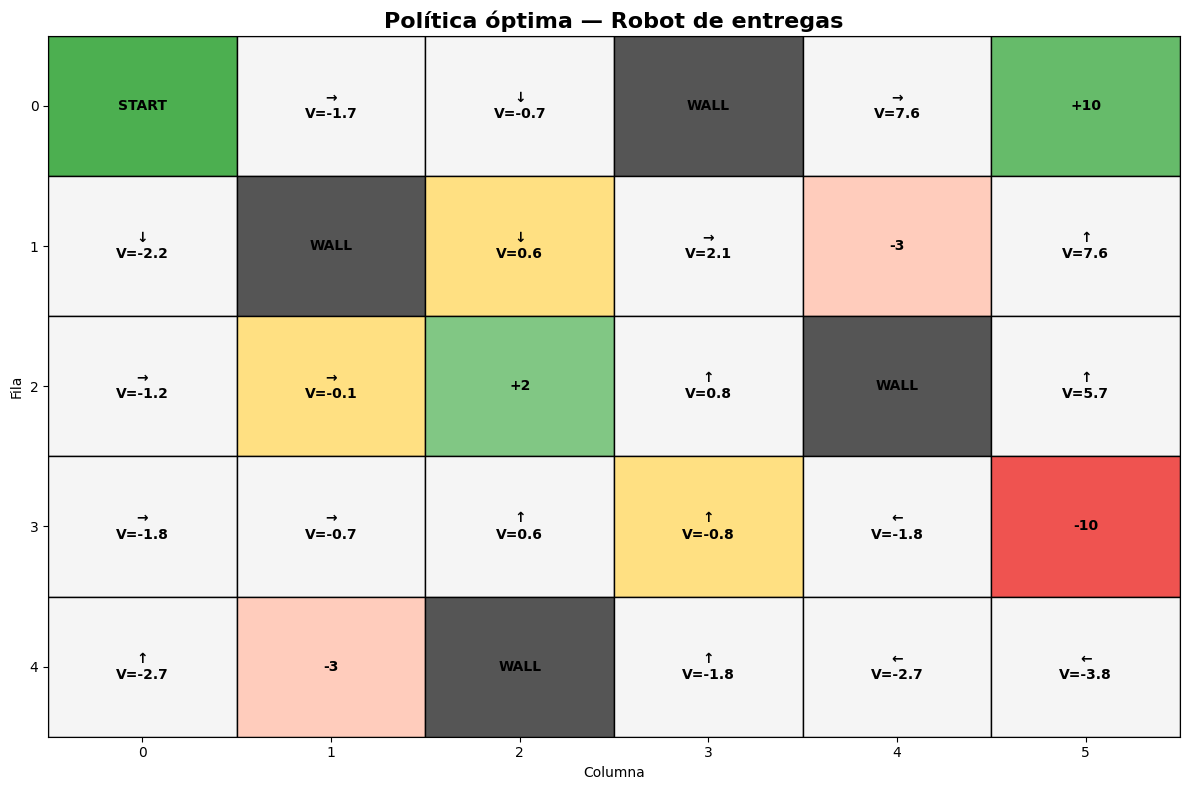

In [27]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def visualize_policy(
    grid,
    policy,
    V
):

    fig, ax = plt.subplots(
        figsize=(12, 8)
    )


    for r in range(grid.height):

        for c in range(grid.width):

            state = (r, c)


            # -----------------------------
            # Color de la celda
            # -----------------------------

            if state in grid.walls:

                color = "#555555"

            elif state == grid.start:

                color = "#4CAF50"

            elif state == (0, 5):

                color = "#66BB6A"

            elif state == (2, 2):

                color = "#81C784"

            elif state == (3, 5):

                color = "#EF5350"

            elif state in grid.danger_states:

                color = "#FFCCBC"

            elif state in grid.slippery_states:

                color = "#FFE082"

            else:

                color = "#F5F5F5"


            ax.add_patch(
                Rectangle(
                    (c, r),
                    1,
                    1,
                    facecolor=color,
                    edgecolor="black"
                )
            )


            # -----------------------------
            # Texto
            # -----------------------------

            if state in grid.walls:

                text = "WALL"

            elif state == grid.start:

                text = "START"

            elif state in grid.terminal_states:

                text = (
                    f"{grid.get_reward(state):+.0f}"
                )

            elif state in grid.danger_states:

                text = "-3"

            else:

                arrow = ARROWS[
                    policy[state]
                ]

                text = (
                    f"{arrow}\n"
                    f"V={V[state]:.1f}"
                )


            ax.text(
                c + 0.5,
                r + 0.5,
                text,
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold"
            )


    ax.set_xlim(0, grid.width)
    ax.set_ylim(grid.height, 0)

    ax.set_xticks(
        np.arange(
            0.5,
            grid.width,
            1
        )
    )

    ax.set_yticks(
        np.arange(
            0.5,
            grid.height,
            1
        )
    )

    ax.set_xticklabels(
        range(grid.width)
    )

    ax.set_yticklabels(
        range(grid.height)
    )

    ax.set_xlabel("Columna")
    ax.set_ylabel("Fila")

    ax.set_title(
        "Política óptima — Robot de entregas",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


visualize_policy(
    grid,
    pi_vi,
    V_vi
)


## Parte 5 — Interpreta la política

Antes de cambiar parámetros, responde:

**1. Desde `START`, ¿el robot busca la *entrega +10* o prefiere la *estación de carga +2?***

Aunque +10 es mayor, está más lejos y el robot acumula costos de -1, además de tener que enfrentarse a incertidumbre y peligros.

**2. ¿Por qué una recompensa menor podría ser óptima?**

Porque el MDP no mira solamente la recompensa final, también considera:

- Distancia
- Costo por paso
- Probabilidad de transición
- Peligros
- Descuento γ

En conclusión, una recompensa menor pero cercana y segura puede tener mayor valor esperado.

**3. ¿En qué estados el piso resbaloso cambia la decisión?**

En: (1,2), (2,1) y (3,3)

Ahí la acción elegida solamente ocurre con 0.60, mientras que en piso normal ocurre con 0.90. Por lo tanto, el robot debe considerar el riesgo de desviarse para esas posiciones.

**4. ¿Qué papel cumple el costo por paso `-1`?**

Es el costo por cada paso.
Hace que el robot prefiera: llegar al objetivo de manera eficiente, en lugar de dar vueltas innecesariamente.

**5. ¿Por qué \(T(s,a,s')\) ya no puede implementarse con las mismas probabilidades para todos los estados?**

Porque el entorno no es igual en todas las celdas.

 *En piso normal:*
- 0.90 → dirección elegida
- 0.05 → izquierda
- 0.05 → derecha

*En piso resbaloso:*

- 0.60 → dirección elegida
- 0.20 → izquierda
- 0.20 → derecha

Por eso: T(s,a,s′) depende del estado actual s.

### Experimento A — Menos costo por paso

Cambia:

```python
living_reward = -0.1
```

Predice la política **antes de ejecutar**.

### Experimento B — Piso muy resbaloso

Cambia la probabilidad de movimiento deseado del piso resbaloso:

```python
0.60 → 0.40
```

y reparte el restante entre las dos desviaciones.

### Experimento C — Más paciencia

Cambia:

```python
gamma = 0.99
```

¿La política valora más la recompensa `+10` distante?

### Bonus

Encuentra aproximadamente el valor de `living_reward` a partir del cual la política desde `START` cambia entre:

- ir a carga `+2`;
- intentar llegar a entrega `+10`.


##Experimento A


In [28]:
grid_A = WarehouseMDP()

grid_A.living_reward = -0.1

V_A, _ = value_iteration(grid_A)
pi_A = extract_policy(grid_A, V_A)

print("Política desde START:")
print(ARROWS[pi_A[grid_A.start]])

Política desde START:
→


**¿Qué esperamos?**

Al reducir el costo de cada paso:
- -1 → -0.1

los caminos largos se vuelven menos costosos u eso ocasiona que la entrega resulte más atractiva

##Experimento B

In [29]:
grid_B = WarehouseMDP()

# 40% movimiento deseado
# 30% desviación izquierda
# 30% desviación derecha

grid_B.slippery_probs = (
    0.40,
    0.30,
    0.30
)

V_B, _ = value_iteration(grid_B)
pi_B = extract_policy(grid_B, V_B)

print("Política desde START:")
print(ARROWS[pi_B[grid_B.start]])

Política desde START:
→


**¿Qué esperamos?**

Que el robot sea más cuidadoso con las zonas resbalosas, porque ahora desviarse es mucho más probable

##Experimento C


In [30]:
grid_C = WarehouseMDP()

grid_C.gamma = 0.99

V_C, _ = value_iteration(grid_C)
pi_C = extract_policy(grid_C, V_C)

print("Política desde START:")
print(ARROWS[pi_C[grid_C.start]])

Política desde START:
→


**¿Qué significa?**

Con:

γ = 0.9

el futuro pierde valor más rápido.

Con:

γ = 0.99

el robot considera mucho más las recompensas futuras. Por eso la recompensa +10 de la entrega se vuelve mucho más deseable aunque esté más lejos

##Bonus

In [31]:
print(
    "living_reward | acción desde START"
)

for reward in np.arange(
    -1.0,
    2.1,
    0.1
):

    test_grid = WarehouseMDP()

    test_grid.living_reward = round(
        reward,
        2
    )

    V, _ = value_iteration(
        test_grid
    )

    policy = extract_policy(
        test_grid,
        V
    )

    action = ARROWS[
        policy[test_grid.start]
    ]

    print(
        f"{reward:+.1f}          | {action}"
    )

living_reward | acción desde START
-1.0          | →
-0.9          | →
-0.8          | →
-0.7          | →
-0.6          | →
-0.5          | →
-0.4          | →
-0.3          | →
-0.2          | →
-0.1          | →
-0.0          | →
+0.1          | →
+0.2          | →
+0.3          | →
+0.4          | →
+0.5          | →
+0.6          | →
+0.7          | →
+0.8          | →
+0.9          | →
+1.0          | →
+1.1          | ↓
+1.2          | ↓
+1.3          | ↓
+1.4          | ↓
+1.5          | ↓
+1.6          | ↓
+1.7          | ↓
+1.8          | ↓
+1.9          | ↓
+2.0          | ↓


#Conclusiones:

**¿Por qué varios experimentos dan la misma flecha?**

Porque cambiar un parámetro no garantiza que cambie la mejor acción, aunque cambiemos living_reward, gamma o el piso resbaloso, puede que siga siendo óptimo comenzar moviéndose hacia la derecha

Pero, algo que si cambia son los valores de los estados, por ejemplo:

Experimento original:
START →  -2.57

Experimento A:
START →  +1.65

La flecha es la misma, pero el valor de estar en START cambia

_Los cambios se pueden observar de mejor manera en la siguiente tabla:_

In [32]:
import pandas as pd

# ============================================
# COMPARACIÓN DE EXPERIMENTOS
# ============================================

experimentos = []

# Configuración original
grid_original = WarehouseMDP()
V_original, iter_original = value_iteration(grid_original)
pi_original = extract_policy(grid_original, V_original)

experimentos.append({
    "Experimento": "Original",
    "Living Reward": grid_original.living_reward,
    "Gamma": grid_original.gamma,
    "Piso resbaloso": "0.60",
    "Acción START": ARROWS[pi_original[grid_original.start]],
    "V(START)": V_original[grid_original.start],
    "Iteraciones": iter_original
})


# Experimento A
grid_A = WarehouseMDP()
grid_A.living_reward = -0.1

V_A, iter_A = value_iteration(grid_A)
pi_A = extract_policy(grid_A, V_A)

experimentos.append({
    "Experimento": "A",
    "Living Reward": grid_A.living_reward,
    "Gamma": grid_A.gamma,
    "Piso resbaloso": "0.60",
    "Acción START": ARROWS[pi_A[grid_A.start]],
    "V(START)": V_A[grid_A.start],
    "Iteraciones": iter_A
})


# Experimento B
grid_B = WarehouseMDP()
grid_B.slippery_probs = (0.40, 0.30, 0.30)

V_B, iter_B = value_iteration(grid_B)
pi_B = extract_policy(grid_B, V_B)

experimentos.append({
    "Experimento": "B",
    "Living Reward": grid_B.living_reward,
    "Gamma": grid_B.gamma,
    "Piso resbaloso": "0.40",
    "Acción START": ARROWS[pi_B[grid_B.start]],
    "V(START)": V_B[grid_B.start],
    "Iteraciones": iter_B
})


# Experimento C
grid_C = WarehouseMDP()
grid_C.gamma = 0.99

V_C, iter_C = value_iteration(grid_C)
pi_C = extract_policy(grid_C, V_C)

experimentos.append({
    "Experimento": "C",
    "Living Reward": grid_C.living_reward,
    "Gamma": grid_C.gamma,
    "Piso resbaloso": "0.60",
    "Acción START": ARROWS[pi_C[grid_C.start]],
    "V(START)": V_C[grid_C.start],
    "Iteraciones": iter_C
})


# Mostrar tabla
tabla = pd.DataFrame(experimentos)

tabla["V(START)"] = tabla["V(START)"].round(3)

display(tabla)

,Experimento,Living Reward,Gamma,Piso resbaloso,Acción START,V(START),Iteraciones
0,Original,-1.0,0.90,0.60,→,-2.575,19
1,A,-0.1,0.90,0.60,→,1.649,25
2,B,-1.0,0.90,0.40,→,-2.706,20
3,C,-1.0,0.99,0.60,→,-1.456,23
